# 02. Conservative shortlist construction

This notebook produces the Section 5.1 experiment. It replays the full 19-policy reserve catalog on season two, constructs simultaneous lower and upper bounds, applies conservative lower-bound elimination, and writes the certified, dominated, and unresolved decision labels.

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
        CODE_ROOT = candidate
        break
    if (candidate / "code" / "src").is_dir() and (candidate / "code" / "notebooks").is_dir():
        CODE_ROOT = candidate / "code"
        break
else:
    raise RuntimeError("Could not find the project code root.")

sys.path.insert(0, str(CODE_ROOT / "src"))

from IPython.display import Image, display

from config import ExperimentConfig, ProjectPaths
from paper_experiments import (
    build_ipinyou_panels,
    run_appendix_b_diagnostics,
    run_conservative_shortlist,
    run_data_audit,
    run_support_localized_threshold_resolution,
    run_validation_readiness,
)
from progress import ProgressLogger

paths = ProjectPaths.from_repo_root(CODE_ROOT)
paths.ensure()
config = ExperimentConfig(full_run=True)
progress = ProgressLogger(enabled=True)
print(f"Code root: {CODE_ROOT}")
print(f"Data archive: {paths.ipinyou_archive}")
print(f"Artifacts: {paths.artifact_dir}")

Code root: <repo>
Data archive: <repo>/data/archive.zip
Artifacts: <repo>/artifacts


[02:13:45] >> Running Section 5.1 conservative shortlist construction.
[02:13:47]    Using cached replay artifacts for 02_season2.
[02:13:47] OK Section 5.1 artifacts are ready. (2.5s elapsed)


,policy_number,policy_label,decision_label,lower_bound_lift,upper_bound_lift
0,P18,Q75 Margin-Gated Floor,certified,0.407129,0.547926
1,P11,Positive Floors To Q75,unresolved,0.285672,0.426549


,policy_number,policy_label,decision_label,daily_mean_lift,lower_bound_lift,upper_bound_lift
0,P18,Q75 Margin-Gated Floor,certified,0.477527,0.407129,0.547926
1,P11,Positive Floors To Q75,unresolved,0.356111,0.285672,0.426549
2,P16,Gap 100 Add 20,dominated,0.097883,0.088253,0.107514
3,P8,Add 20 To All Floors,dominated,0.097429,0.087558,0.107005
4,P17,Q50 Margin-Gated Floor,dominated,0.101607,0.077049,0.126165
5,P13,All Low Floors To Q50,dominated,0.101607,0.077049,0.126165
6,P5,Uniform +30%,dominated,0.069015,0.060048,0.075848
7,P10,Positive Floors To Q50,dominated,0.073458,0.049086,0.097830
8,P4,Uniform +20%,dominated,0.043901,0.037995,0.048967
9,P15,Gap 50 Add 10,dominated,0.040763,0.035507,0.046019


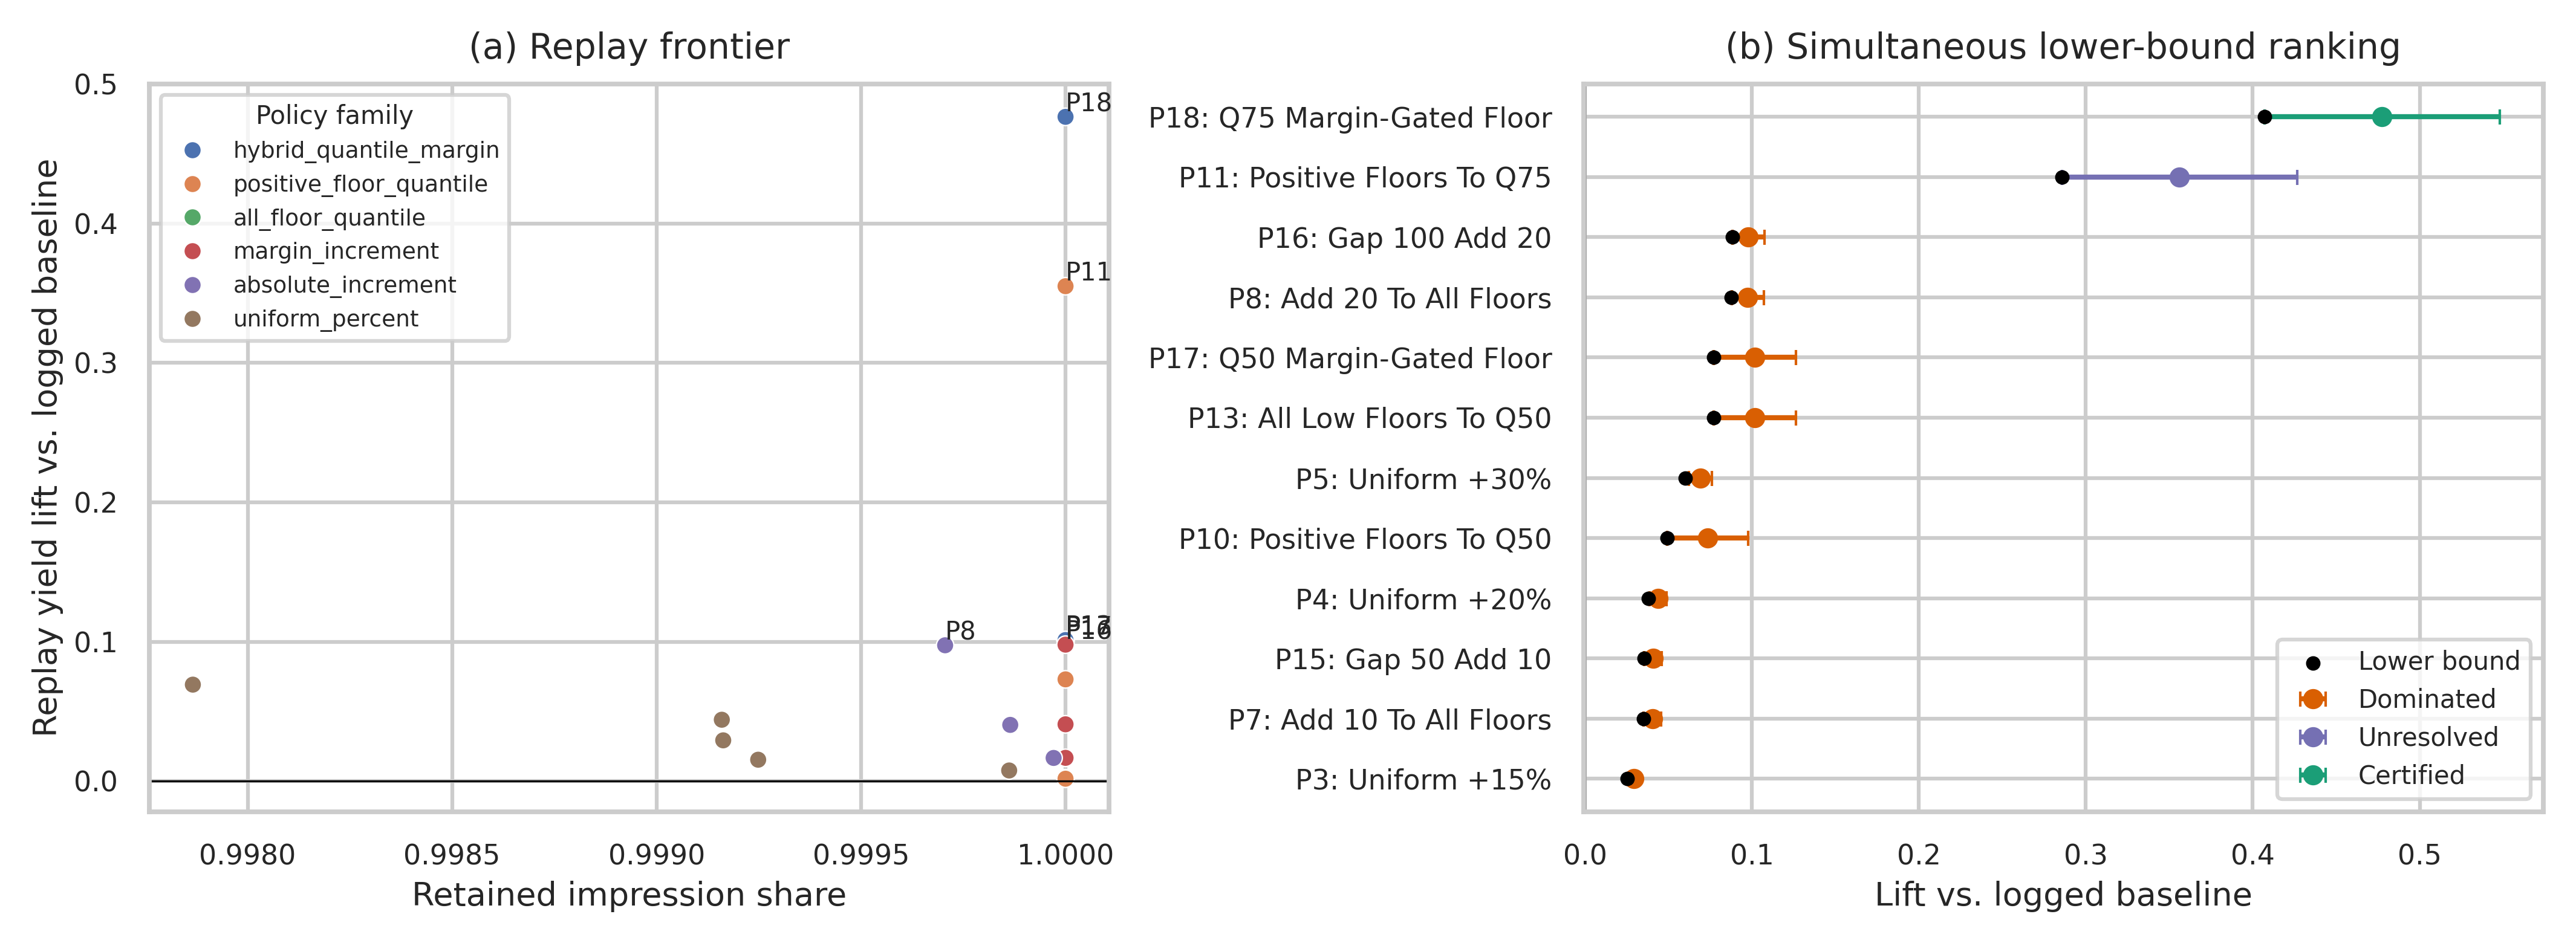

In [2]:
artifacts = run_conservative_shortlist(paths, config, progress)

display(artifacts["shortlist"][["policy_number", "policy_label", "decision_label", "lower_bound_lift", "upper_bound_lift"]])
display(artifacts["decisions"][["policy_number", "policy_label", "decision_label", "daily_mean_lift", "lower_bound_lift", "upper_bound_lift"]].head(12))
display(Image(filename=str(artifacts["figure"])))